In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### 

In [2]:
from moabb.paradigms import P300,LeftRightImagery, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = MotorImagery(resample=250)
dataset = BNCI2014_001()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)

session = meta['session'].unique()[0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


Choosing from all possible events


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns


/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 48 events (all good), 2 – 6 s (baseline off), ~8.1 MB, data loaded,
 'left_hand': 12
 'right_hand': 12
 'feet': 12
 'tongue': 12>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 48 events (all good), 2 – 6 s (baseline off), ~8.1 MB, data loaded,
 'left_hand': 12
 'right_hand': 12
 'feet': 12
 'tongue': 12>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 48 events (all good), 2 – 6 s (baseline off), ~8.1 MB, data loaded,
 'left_hand': 12
 'right_hand': 12
 'feet': 12
 'tongue': 12>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 48 events (all good), 2 – 6 s (baseline off), ~8.1 MB, data loaded,
 'lef

Adding metadata with 3 columns
576 matching events found
No baseline correction applied


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor
from mne.decoding import Scaler

X = epochs.get_data()
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], normalize=True, log=True, n_freqs=4, bin_freq=4)
X = tl.tensor(X)
y = labels
X.shape

(288, 22, 4, 16)

In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning

env: PYTHONWARNINGS=ignore::FutureWarning


In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(alpha=.01),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=2,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    #rank_grid=[1,2,3],
    verbose=True,
    extra_train_info=False,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True, n_splits=10),
    truncate=True,
    clf=clf,
    scoring='accuracy'

)
bttda.fit(X,y, test=True)

Model selection block 1/2...

Trying rank (1, 1, 1)	score: 0.5217
Trying rank (2, 2, 2)	score: 0.5261
Trying rank (4, 4, 4)	score: 0.5565
Trying rank (8, 4, 8)	score: 0.5522
Trying rank (16, 4, 16)	score: 0.5174
Trying rank (22, 4, 16)	score: 0.6087

Selected rank (22, 4, 16) with score 0.6087
New ranks: [(22, 4, 16)]


Model selection block 2/2...

Trying rank (1, 1, 1)	score: 0.6087
Trying rank (2, 2, 2)	score: 0.6217
Trying rank (4, 4, 4)	score: 0.6304
Trying rank (8, 4, 8)	score: 0.6348
Trying rank (16, 4, 16)	score: 0.6435
Trying rank (22, 4, 16)	score: 0.6261

Selected rank (16, 4, 16) with score 0.6435
New ranks: [(22, 4, 16), (16, 4, 16)]


Fitting block 1/2...
Fitting block 2/2...


GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF(alpha=0.001)),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function NumpyBackend.to_numpy at 0x7fe550cb4040>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (16, 4, 16),
                         'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                         'toeplitz': None, 'tol': 1e-08, 'verbose': False},
            max_blocks=2, n_jobs=1, scoring='accuracy', verbose=True)

In [6]:
bttda.model_select_info_.groupby(['block', 'rank']).val_score.aggregate('mean')

block  rank       
0      (1, 1, 1)      0.521739
       (2, 2, 2)      0.526087
       (4, 4, 4)      0.556522
       (8, 4, 8)      0.552174
       (16, 4, 16)    0.517391
       (22, 4, 16)    0.608696
1      (1, 1, 1)      0.608696
       (2, 2, 2)      0.621739
       (4, 4, 4)      0.630435
       (8, 4, 8)      0.634783
       (16, 4, 16)    0.643478
       (22, 4, 16)    0.626087
Name: val_score, dtype: float64

In [7]:
Xt = bttda.transform(X)

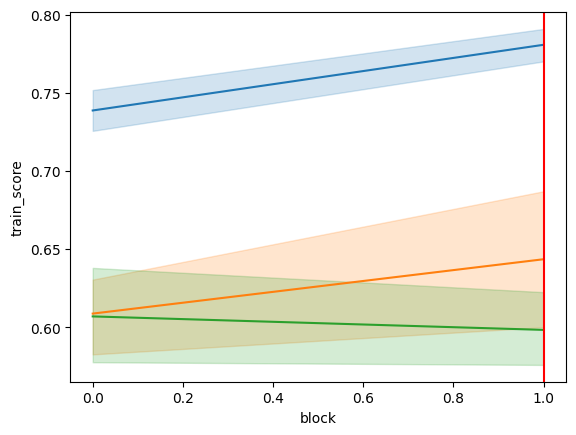

In [8]:
import seaborn as sns 
import matplotlib.pyplot as plt
df_select = bttda.model_select_info_best_
plt.style.use('default')
sns.lineplot(data=df_select, x='block',y='train_score')
sns.lineplot(data=df_select, x='block',y='val_score')
sns.lineplot(data=df_select, x='block',y='test_score')

plt.axvline(bttda.n_blocks_-1, color='red')

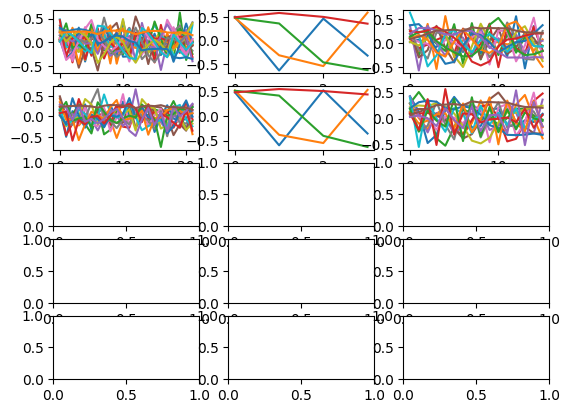

In [9]:
fig, axs = plt.subplots(5,3, sharey=False)
for b,block in enumerate(bttda.blocks_[:5]):
    for k in range(3):
        axs[b,k].plot(tl.to_numpy(block.aps_[k]))

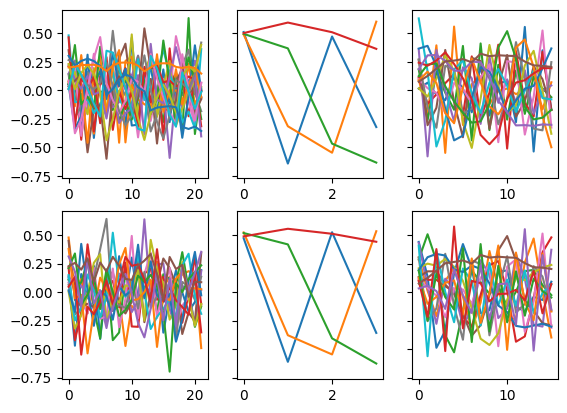

In [10]:
fig, axs = plt.subplots(bttda.n_blocks_,3, sharey=True)
for b,block in enumerate(bttda.blocks_):
    for k in range(3):
        axs[b,k].plot(tl.to_numpy(block.weights_[k]))

block  rank  n_features
0      2     1             0.956944
1      2     1             0.956944
2      2     1             0.956944
3      3     1             0.956944
Name: val_score, dtype: float64